In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

In [2]:
# load the text file
with open("microbench_result.txt", "r") as f:
    lines = f.readlines()

In [3]:
data = []
current_threads = None
sam_times = {}
spc_times = {}
nnz_map = {}

# Regex patterns
sam_re = re.compile(r'(\w+/\w+|\w+) Sparsity Pattern \(SAM computation\): ([\d.]+) s')
spc_re = re.compile(r'(\w+/\w+|\w+) Sparsity Pattern \(Sparsity pattern computation\): ([\d.]+) s')
nnz_re = re.compile(r'(\w+/\w+|\w+) Sparsity Pattern \(nnz\): (\d+)')

In [4]:
for line in lines:
    line = line.strip()
    
    # Changing of thread counts
    # reset execution times
    if line.startswith("Threads:"):
        current_threads = int(line.split(":")[1])
        sam_times = {}
        spc_times = {}
    
    # match sam computation time
    match = sam_re.match(line)
    if match:
        pattern = match.group(1)
        sam_times[pattern] = float(match.group(2))
        
    # match sparsity pattern computation time
    match = spc_re.match(line)
    if match:
        pattern = match.group(1)
        spc_times[pattern] = float(match.group(2))
    
    for pattern in sam_times:
        if pattern in spc_times:
            data.append({
                "Pattern type" : pattern,
                "Threads" : current_threads,
                "SAM execution time (s)" : sam_times[pattern],
                "Pattern computation time (s)" : spc_times[pattern],
                "nnz" : None
            })

In [5]:
# check nnz at the end of file
for line in lines:
    line = line.strip()
    match = nnz_re.match(line)
    if match:
        pattern = match.group(1)
        nnz_map[pattern] = int(match.group(2))

for row in data:
    row["nnz"] = nnz_map.get(row["Pattern type"], None)

In [6]:
df = pd.DataFrame(data)
df = df.sort_values(by=["Pattern type", "Threads"]).reset_index(drop=True)

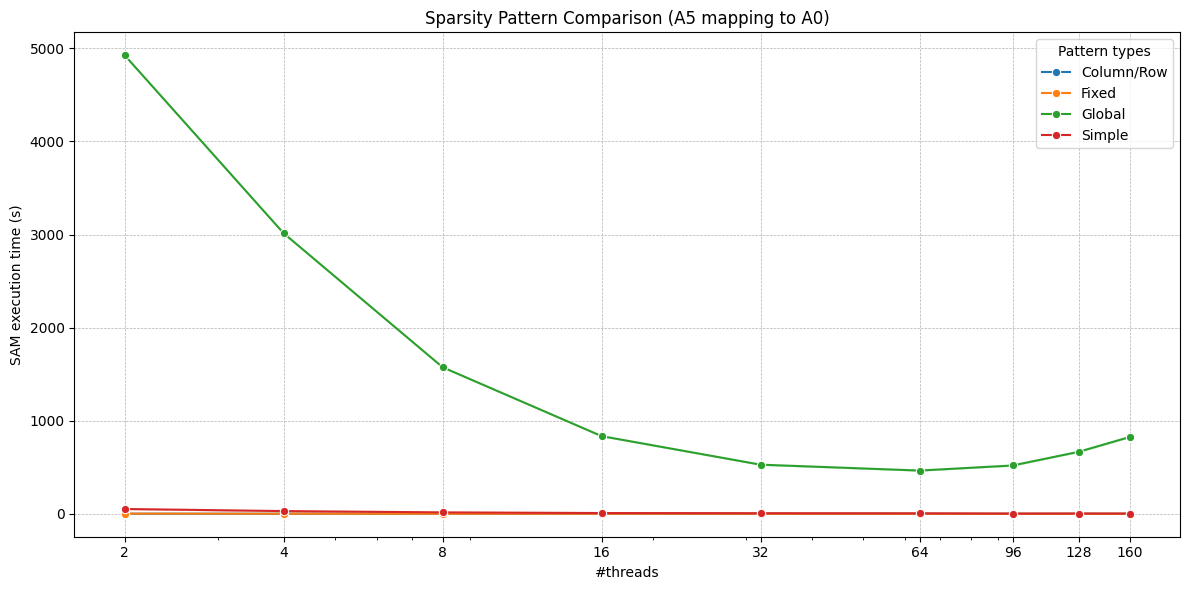

In [7]:
# Plot sam computation time compared to differnt sparsity patterns
thread_vals = sorted(df["Threads"].unique())
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Threads", y="SAM execution time (s)", hue="Pattern type", marker="o")
plt.xscale("log")
plt.title("Sparsity Pattern Comparison (A5 mapping to A0)")
plt.xlabel('#threads')
plt.ylabel("SAM execution time (s)")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xticks(thread_vals, labels=[str(t) for t in thread_vals])
plt.legend(title="Pattern types")
plt.tight_layout()
plt.show()

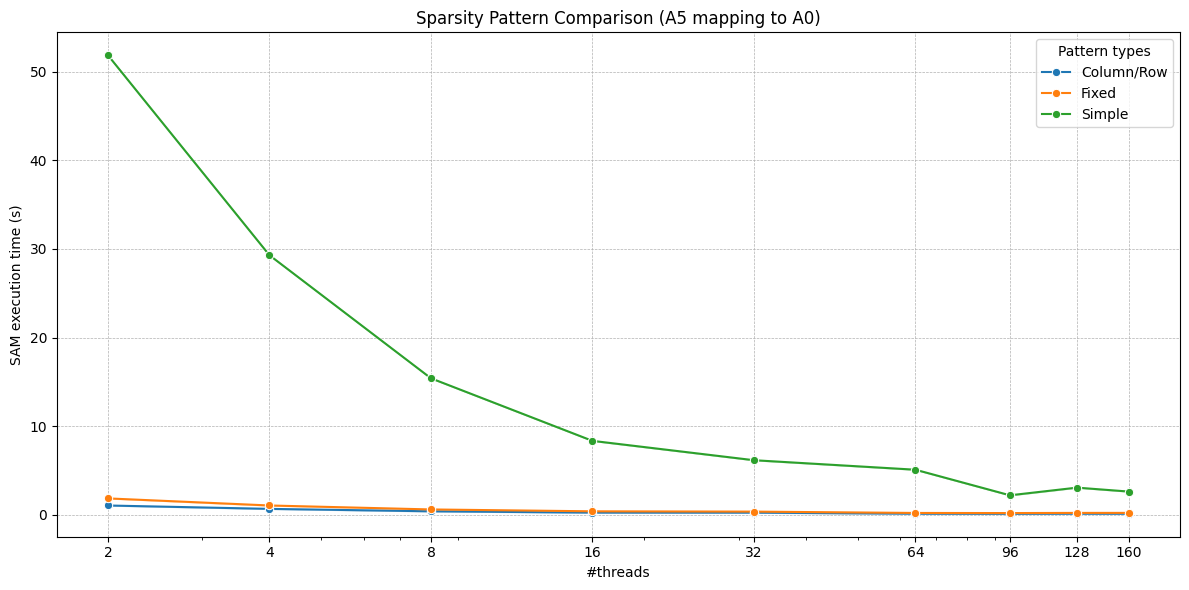

In [8]:
# Plot sam computation time compared to differnt sparsity patterns (except global sparsity pattern)
df_except_global = df[df["Pattern type"] != "Global"]
thread_vals = sorted(df_except_global["Threads"].unique())
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_except_global, x="Threads", y="SAM execution time (s)", hue="Pattern type", marker="o")
plt.xscale("log")
plt.title("Sparsity Pattern Comparison (A5 mapping to A0)")
plt.xlabel('#threads')
plt.ylabel("SAM execution time (s)")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xticks(thread_vals, labels=[str(t) for t in thread_vals])
plt.legend(title="Pattern types")
plt.tight_layout()
plt.show()

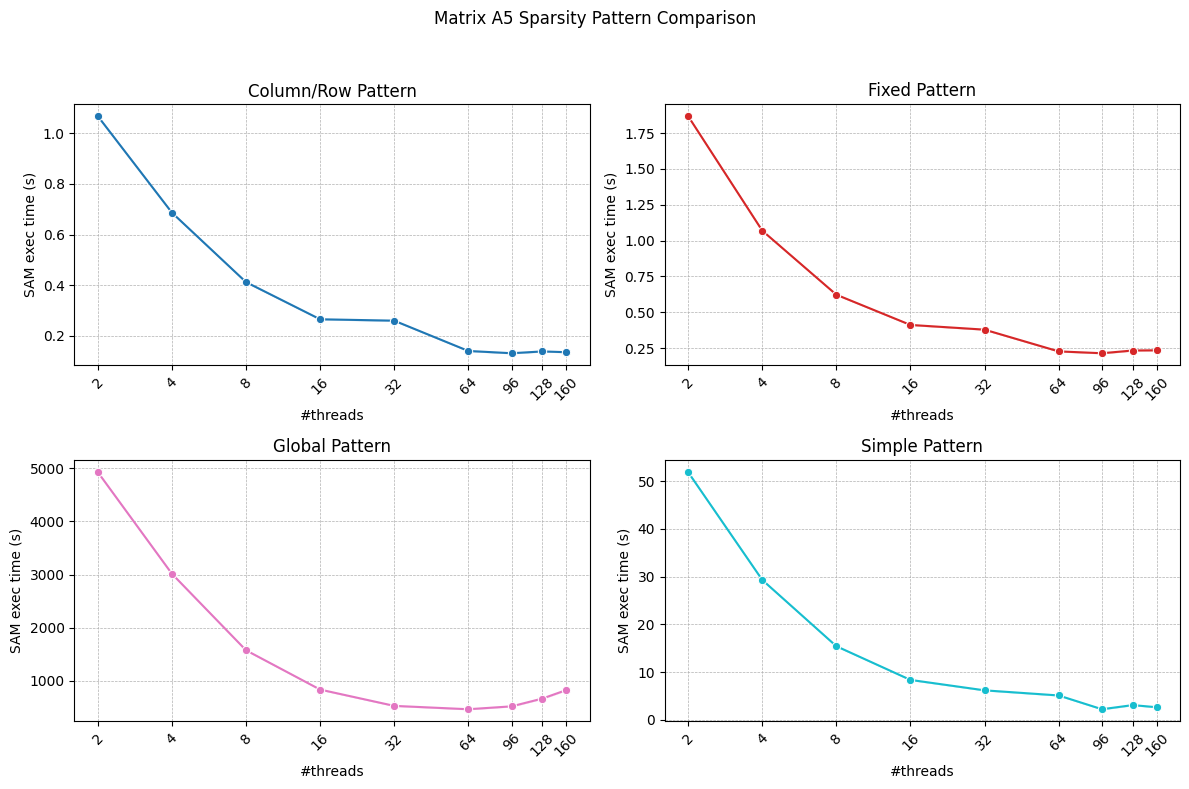

In [9]:
patterns = df["Pattern type"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = cm.tab10(np.linspace(0, 1, len(patterns)))

for ax, pattern, color in zip(axes, patterns, colors):
    subset = df[df["Pattern type"] == pattern]
    thread_vals = sorted(subset["Threads"].unique())
    sns.lineplot(data=subset, x="Threads", y="SAM execution time (s)", marker="o", ax=ax, color=color)
    ax.set_xscale("log")
    ax.set_xticks(thread_vals)
    ax.set_xticklabels([str(t) for t in thread_vals], rotation=45)
    ax.minorticks_off()
    ax.set_title(f"{pattern} Pattern")
    ax.set_xlabel("#threads")
    ax.set_ylabel("SAM exec time (s)")
    ax.grid(True, linestyle='--', linewidth=0.5)
    
plt.suptitle('Matrix A5 Sparsity Pattern Comparison')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
df_speedup = df.copy()
base_times = df[df["Threads"] == 2].set_index("Pattern type")["SAM execution time (s)"].to_dict()
df_speedup["Speedup"] = df_speedup.apply(
    lambda row: base_times[row["Pattern type"]] /
    row["SAM execution time (s)"] if row["Pattern type"] in base_times else None,
    axis=1
)

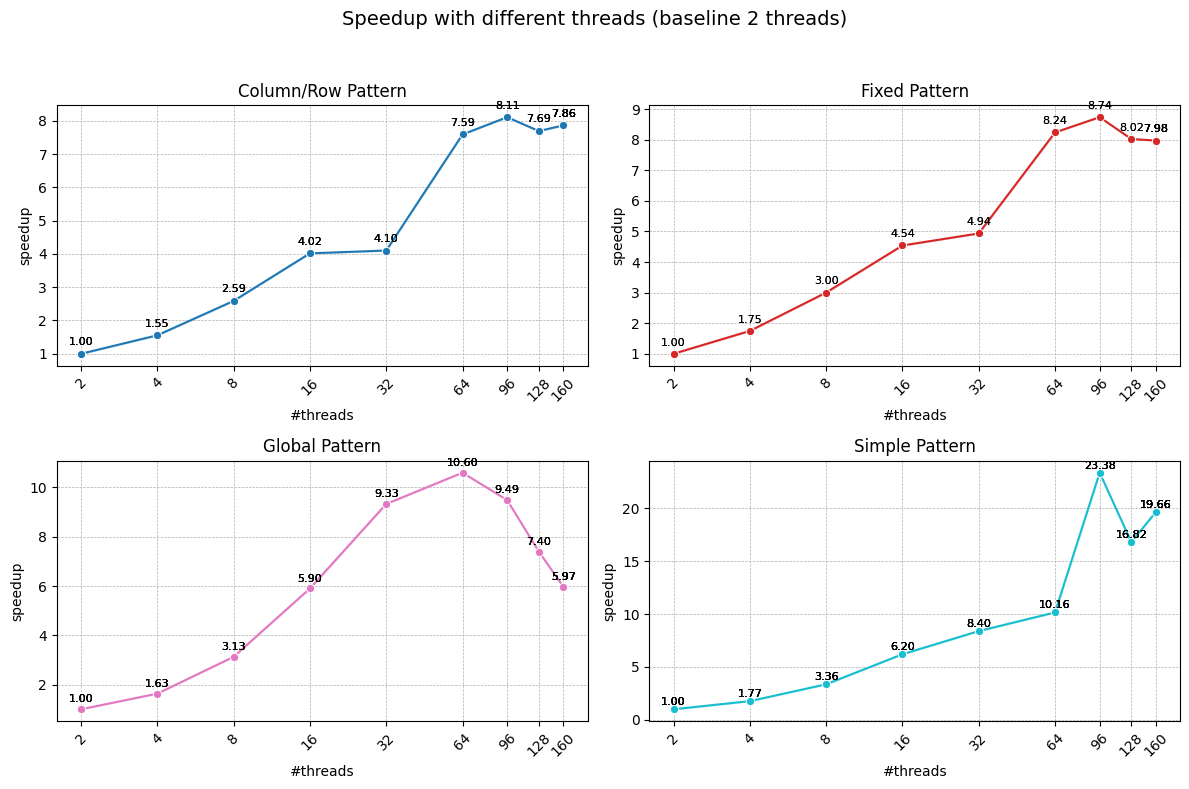

In [12]:
patterns = df_speedup["Pattern type"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = cm.tab10(np.linspace(0, 1, len(patterns)))

for ax, pattern, color in zip(axes, patterns, colors):
    subset = df_speedup[df_speedup["Pattern type"] == pattern]
    thread_vals = sorted(subset["Threads"].unique())
    sns.lineplot(data=subset, x="Threads", y="Speedup",
                 marker="o", ax=ax, color=color)
    for _, row in subset.iterrows():
        ax.text(row["Threads"], row["Speedup"] + 0.2, f"{row['Speedup']:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xscale("log")
    ax.set_xticks(thread_vals)
    ax.set_xticklabels([str(t) for t in thread_vals], rotation=45)
    ax.minorticks_off()
    ax.set_title(f"{pattern} Pattern")
    ax.set_xlabel("#threads")
    ax.set_ylabel("speedup")
    ax.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle('Speedup with different threads (baseline 2 threads)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

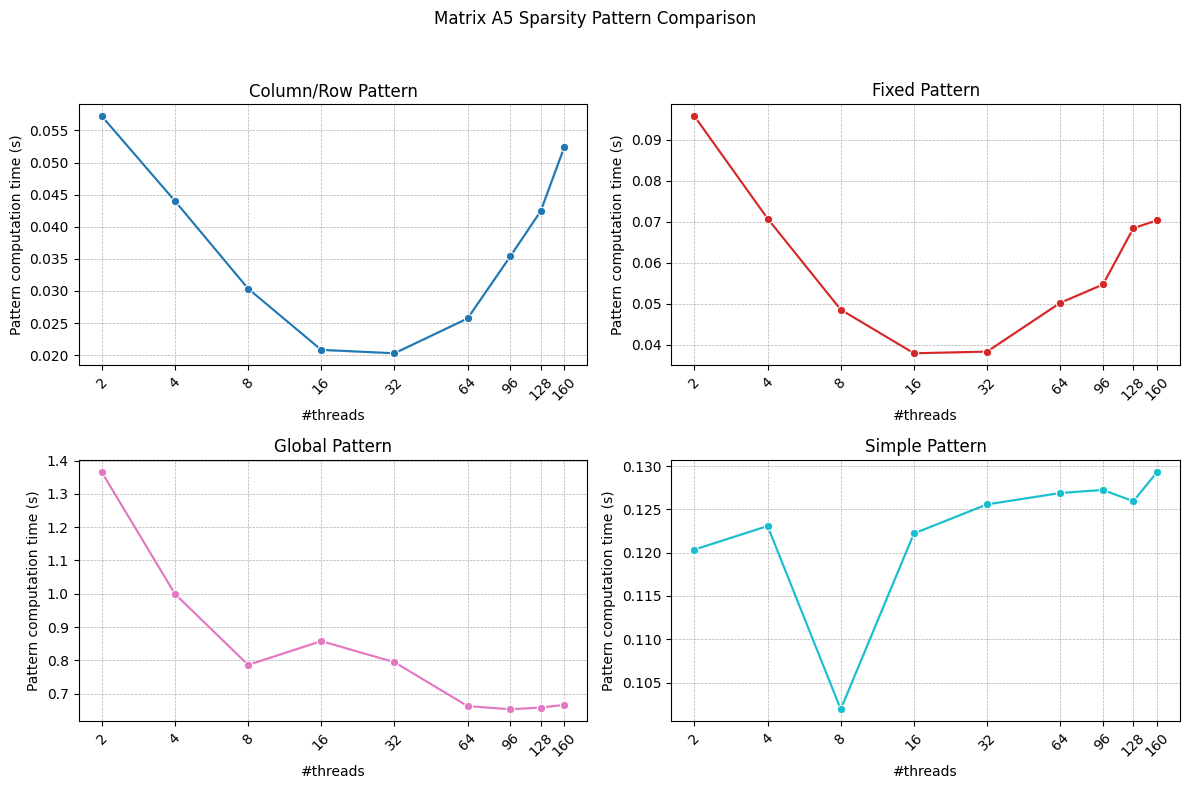

In [17]:
patterns = df["Pattern type"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = cm.tab10(np.linspace(0, 1, len(patterns)))

for ax, pattern, color in zip(axes, patterns, colors):
    subset = df[df["Pattern type"] == pattern]
    thread_vals = sorted(subset["Threads"].unique())
    sns.lineplot(data=subset, x="Threads",
                 y="Pattern computation time (s)", marker="o", ax=ax, color=color)
    ax.set_xscale("log")
    ax.set_xticks(thread_vals)
    ax.set_xticklabels([str(t) for t in thread_vals], rotation=45)
    ax.minorticks_off()
    ax.set_title(f"{pattern} Pattern")
    ax.set_xlabel("#threads")
    ax.set_ylabel("Pattern computation time (s)")
    ax.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle('Matrix A5 Sparsity Pattern Comparison')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

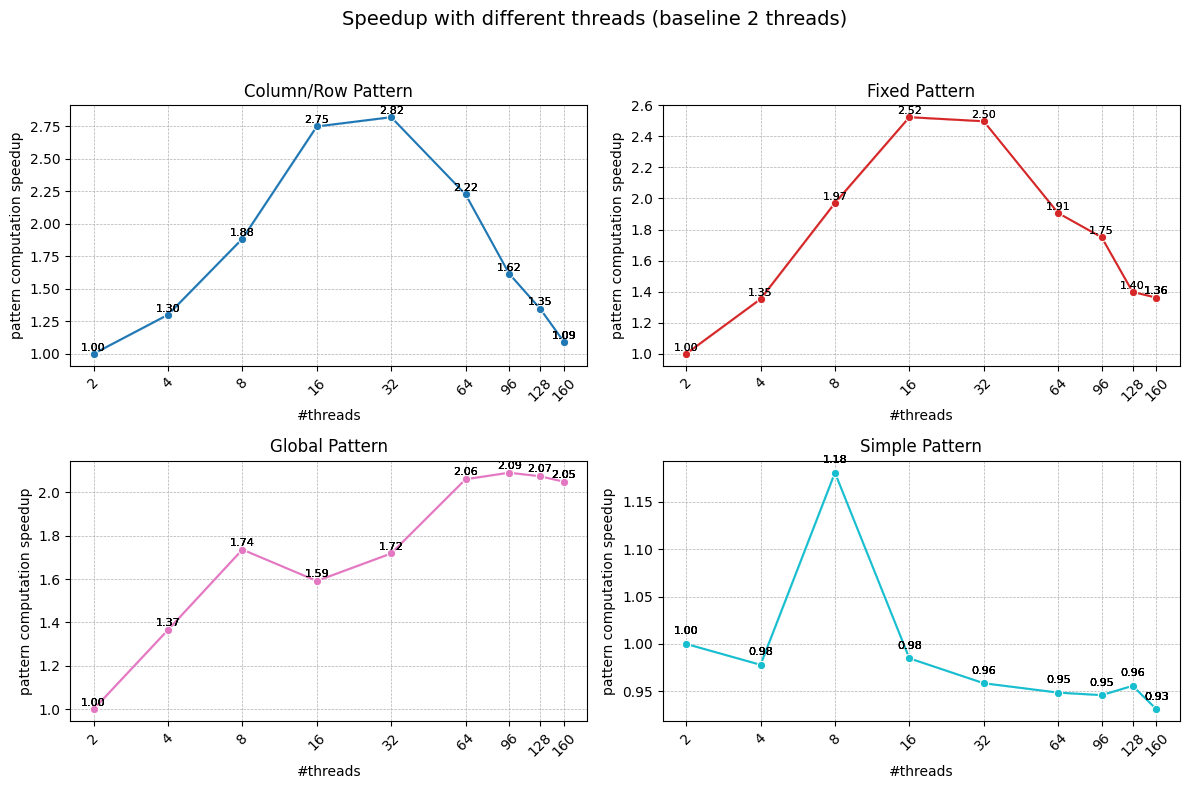

In [22]:
df_speedup = df.copy()
base_times = df[df["Threads"] == 2].set_index(
    "Pattern type")["Pattern computation time (s)"].to_dict()
df_speedup["Speedup"] = df_speedup.apply(
    lambda row: base_times[row["Pattern type"]] /
    row["Pattern computation time (s)"] if row["Pattern type"] in base_times else None,
    axis=1
)

patterns = df_speedup["Pattern type"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = cm.tab10(np.linspace(0, 1, len(patterns)))

for ax, pattern, color in zip(axes, patterns, colors):
    subset = df_speedup[df_speedup["Pattern type"] == pattern]
    thread_vals = sorted(subset["Threads"].unique())
    sns.lineplot(data=subset, x="Threads", y="Speedup",
                 marker="o", ax=ax, color=color)
    for _, row in subset.iterrows():
        ax.text(row["Threads"], row["Speedup"] + 0.008,
                f"{row['Speedup']:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xscale("log")
    ax.set_xticks(thread_vals)
    ax.set_xticklabels([str(t) for t in thread_vals], rotation=45)
    ax.minorticks_off()
    ax.set_title(f"{pattern} Pattern")
    ax.set_xlabel("#threads")
    ax.set_ylabel("pattern computation speedup")
    ax.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle('Speedup with different threads (baseline 2 threads)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_4595/3248052834.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


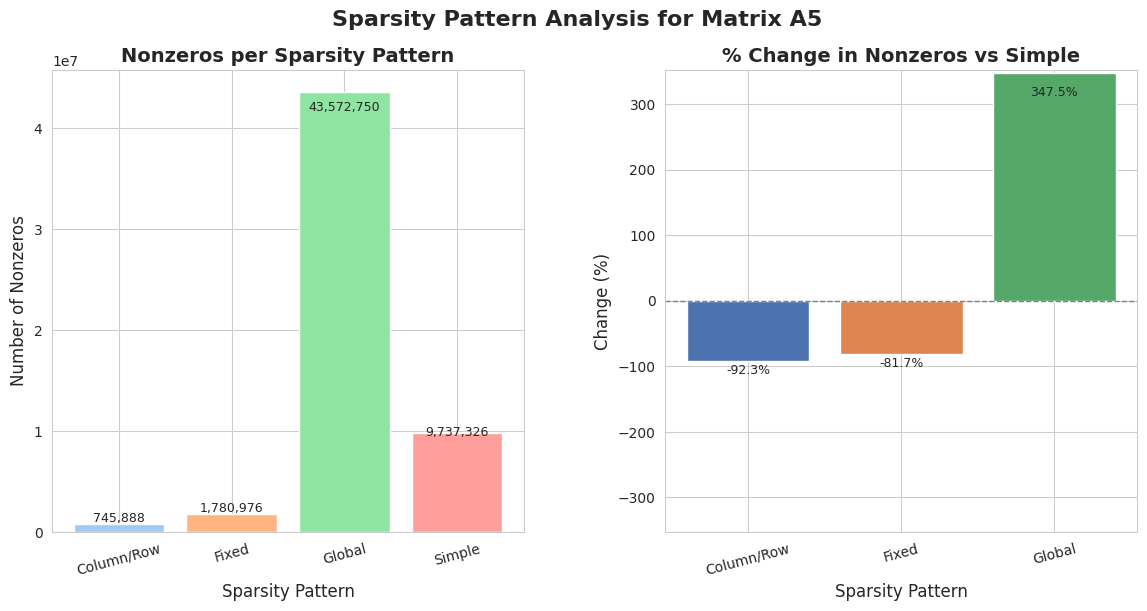

In [41]:
# Set a clean Seaborn style
sns.set_style("whitegrid")

# Create the figure and gridspec layout
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, wspace=0.3)

# Subplots
axs_0_0 = fig.add_subplot(gs[0, 0])
axs_0_1 = fig.add_subplot(gs[0, 1])

# 1. Nonzeros bar plot
patterns = df["Pattern type"].unique()
pattern_labels = [p.replace("Sparsity Pattern", "").strip() for p in patterns]
nnzs = [df[df["Pattern type"] == pattern]["nnz"].iloc[0]
        for pattern in patterns]

bar1 = axs_0_0.bar(pattern_labels, nnzs, color=sns.color_palette("pastel"))

axs_0_0.set_title('Nonzeros per Sparsity Pattern', fontsize=14, weight='bold')
axs_0_0.set_ylabel('Number of Nonzeros', fontsize=12)
axs_0_0.set_xlabel('Sparsity Pattern', fontsize=12)
axs_0_0.tick_params(axis='x', rotation=15)

# Annotate bars
for bar in bar1:
    height = bar.get_height()
    axs_0_0.text(bar.get_x() + bar.get_width() / 2, height - 0.05 * height,
                 f'{height:,}', ha='center', va='bottom', fontsize=9)

# 2. % Change in nonzeros vs Simple
simple_nnz = df[df["Pattern type"] == "Simple"]["nnz"].iloc[0]
other_patterns = [p for p in patterns if p != "Simple"]
other_labels = [p.replace("Sparsity Pattern", "").strip()
                for p in other_patterns]
other_nnz_values = [df[df["Pattern type"] == p]["nnz"].iloc[0]
                    for p in other_patterns]
nnz_percentage = [100 * (val - simple_nnz) /
                  simple_nnz for val in other_nnz_values]

bar2 = axs_0_1.bar(other_labels, nnz_percentage,
                   color=sns.color_palette("deep"))

axs_0_1.set_title('% Change in Nonzeros vs Simple', fontsize=14, weight='bold')
axs_0_1.set_ylabel('Change (%)', fontsize=12)
axs_0_1.set_xlabel('Sparsity Pattern', fontsize=12)
axs_0_1.axhline(0, color='gray', linestyle='--', linewidth=1)
axs_0_1.set_xticks(range(len(other_labels)))
axs_0_1.set_xticklabels(other_labels, rotation=15)

# Dynamic y-limits
ylim_margin = max(abs(min(nnz_percentage)), abs(max(nnz_percentage))) + 5
axs_0_1.set_ylim(-ylim_margin, ylim_margin)

# Annotate bars
for i, val in enumerate(nnz_percentage):
    y_offset = -40 if val >= 0 else -4
    va_align = 'bottom' if val >= 0 else 'top'
    axs_0_1.text(i, val + y_offset, f'{val:.1f}%',
                 ha='center', va=va_align, fontsize=9)

# Super title
plt.suptitle('Sparsity Pattern Analysis for Matrix A5',
             fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()